Mean Squared Error (MSE): 38.487630524897156
R-squared (R2): 0.8453135554215914


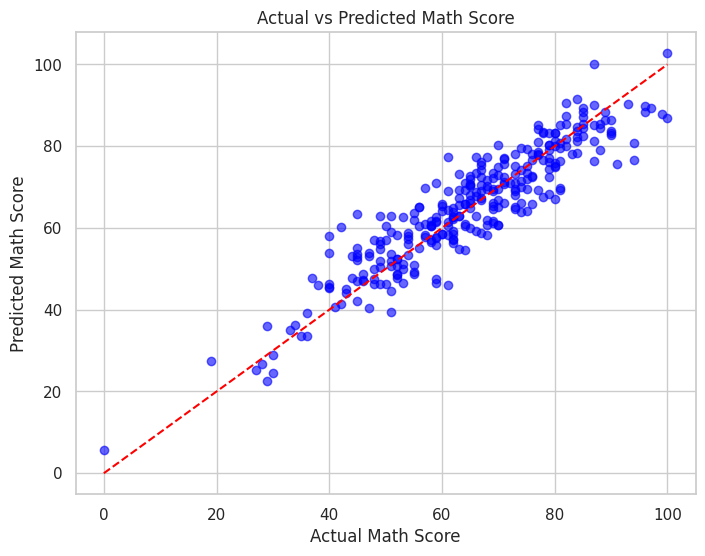

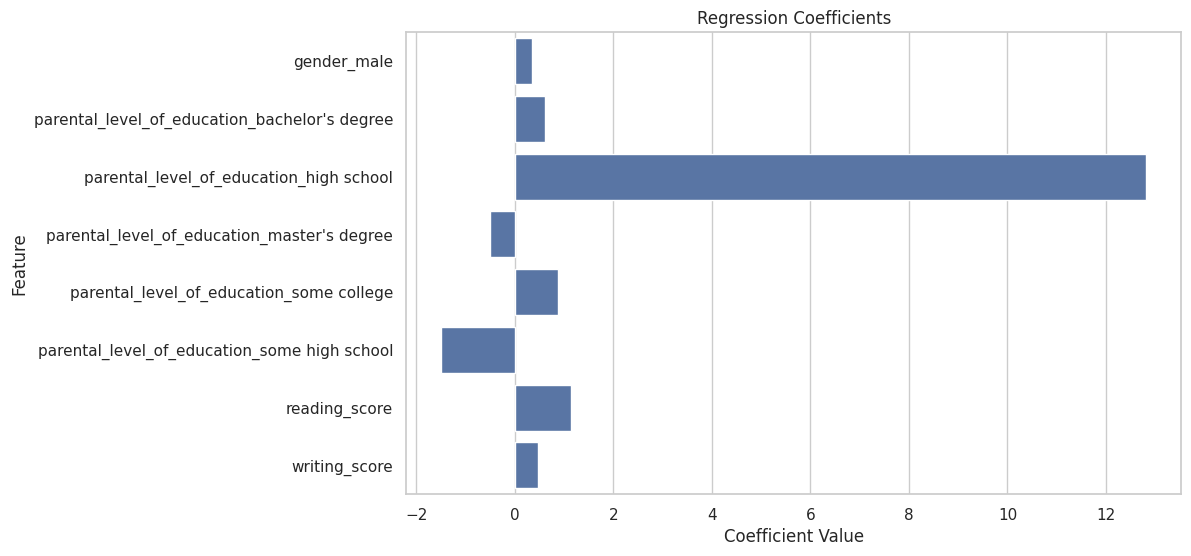

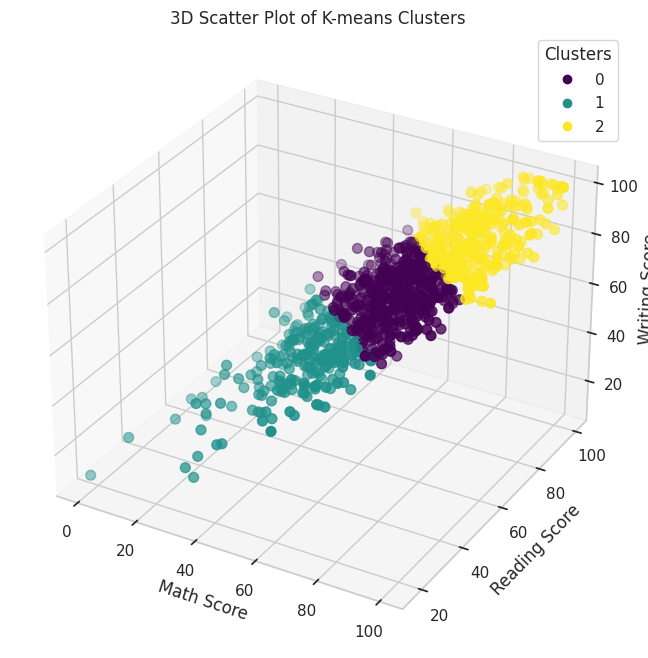

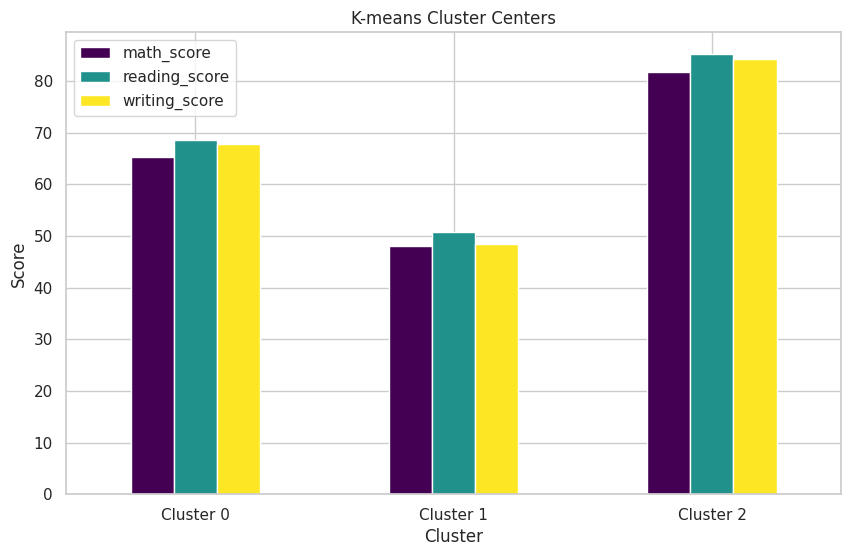

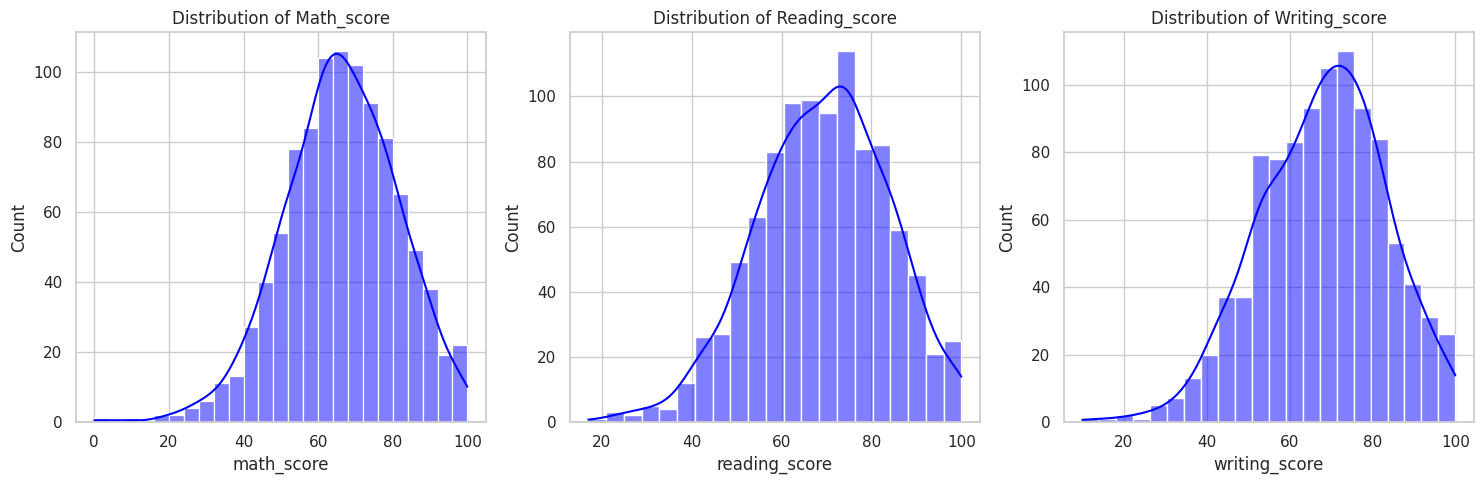

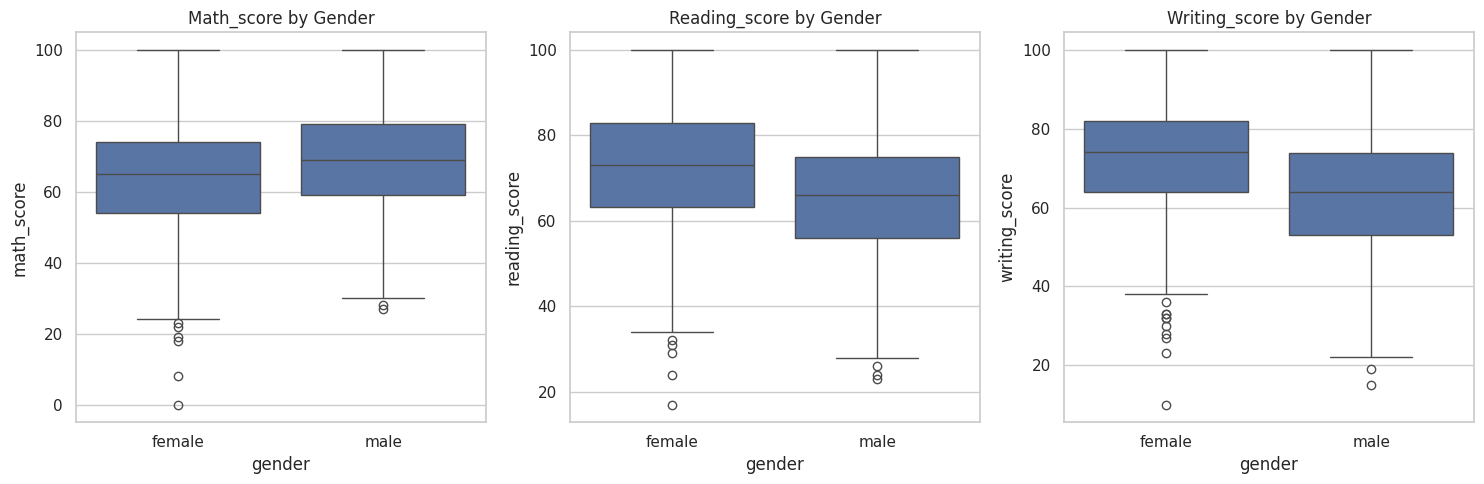

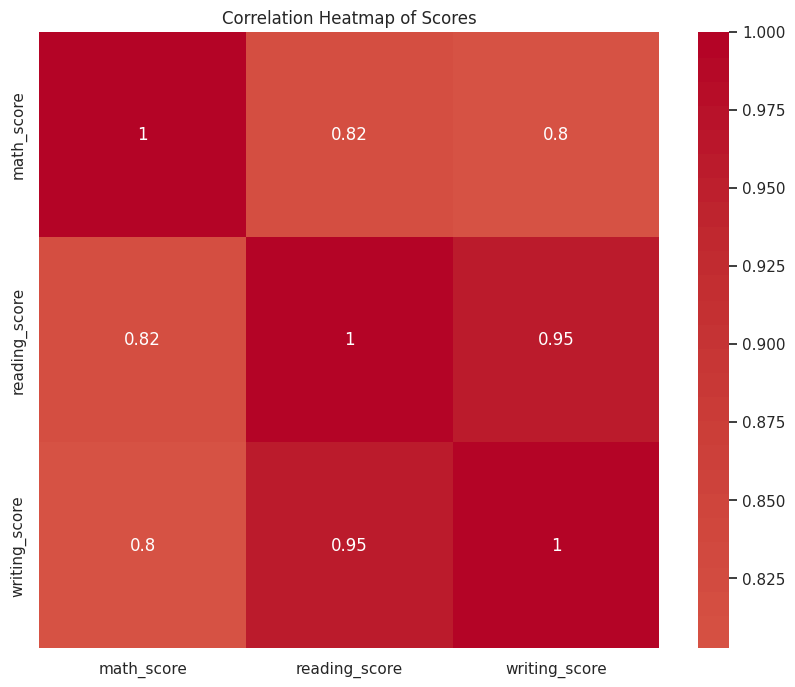

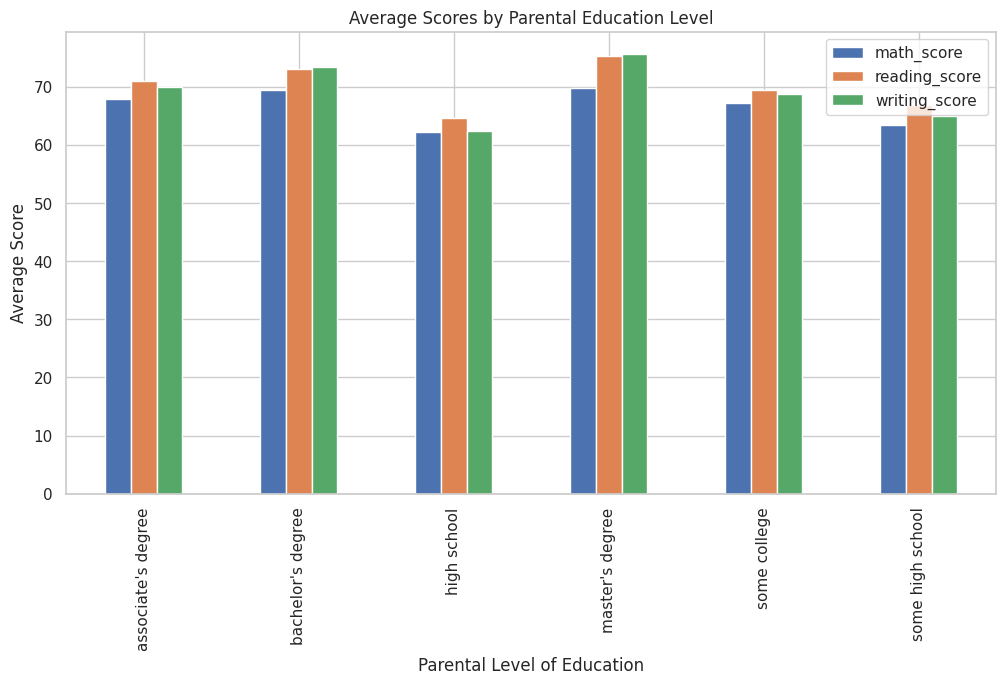

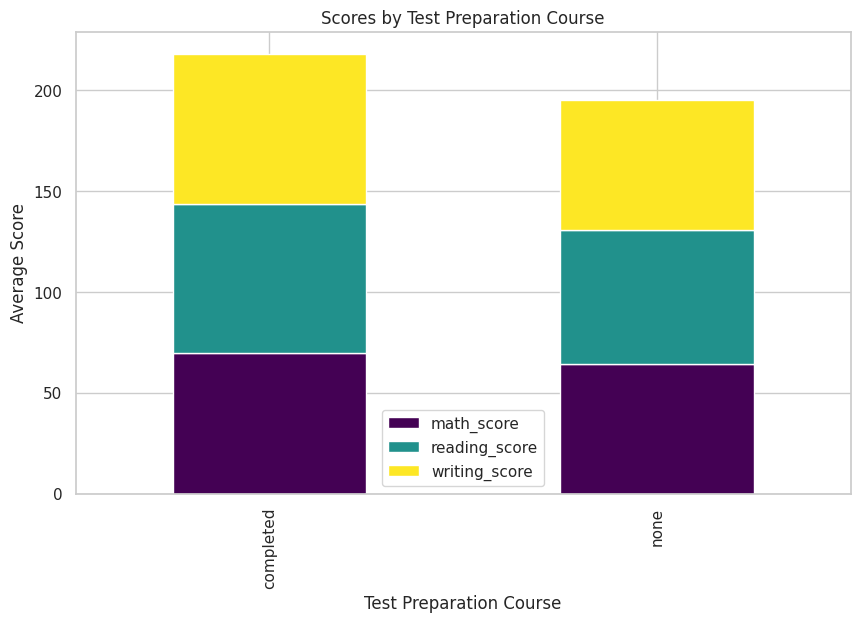

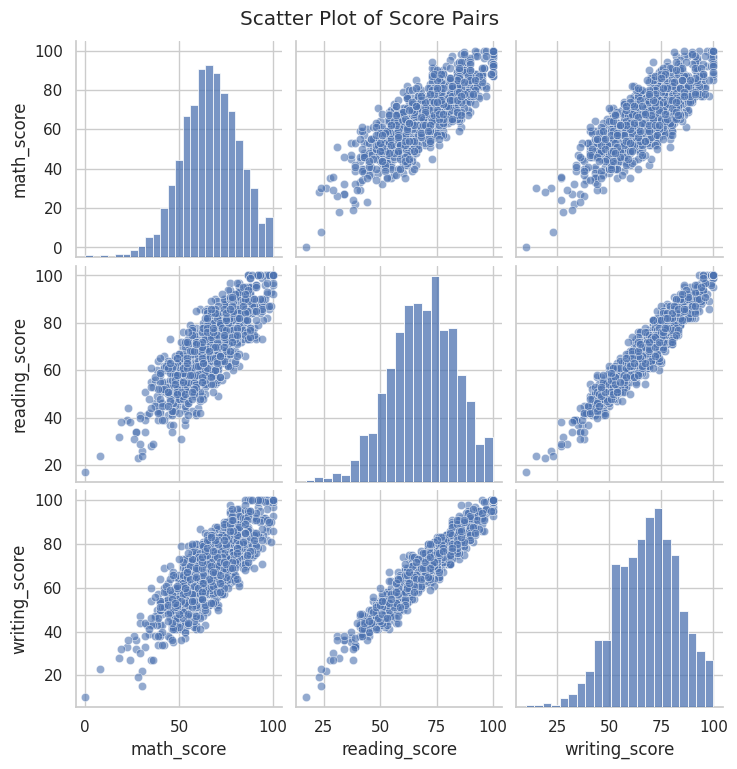

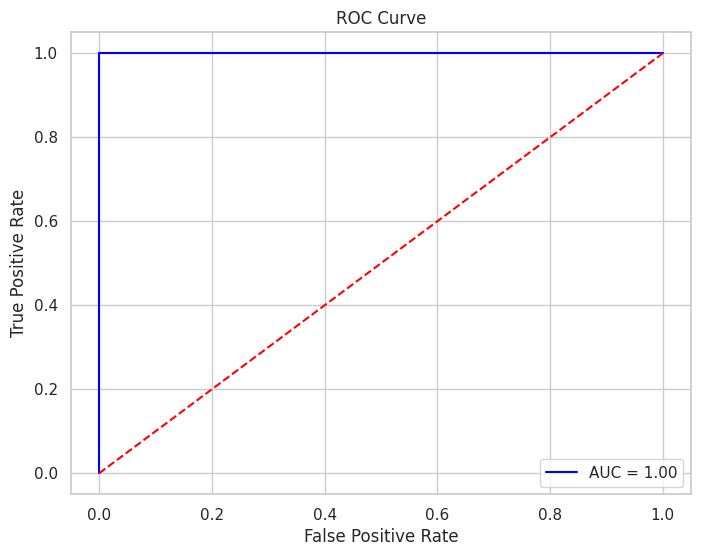

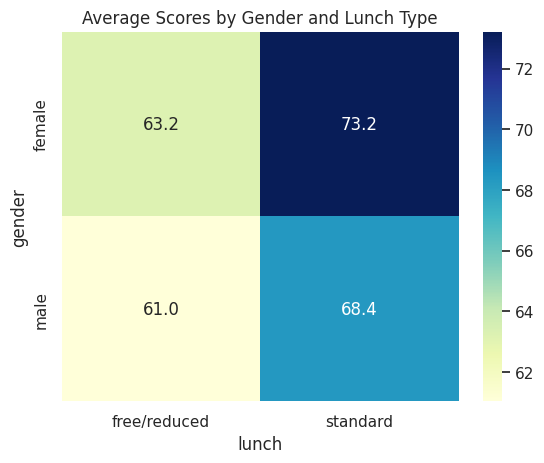

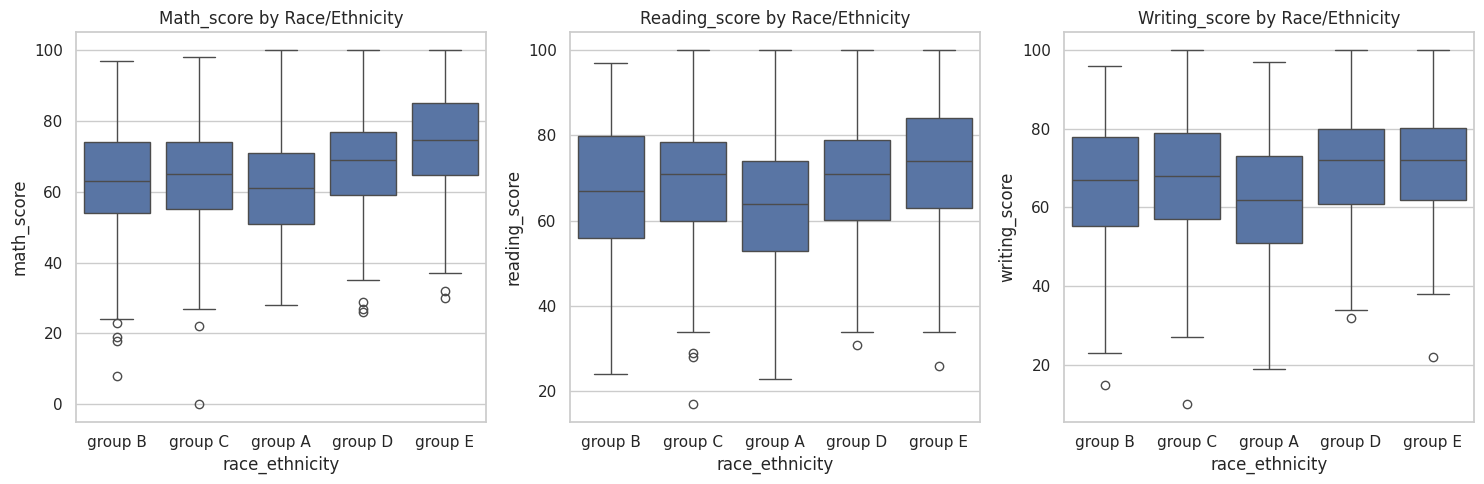

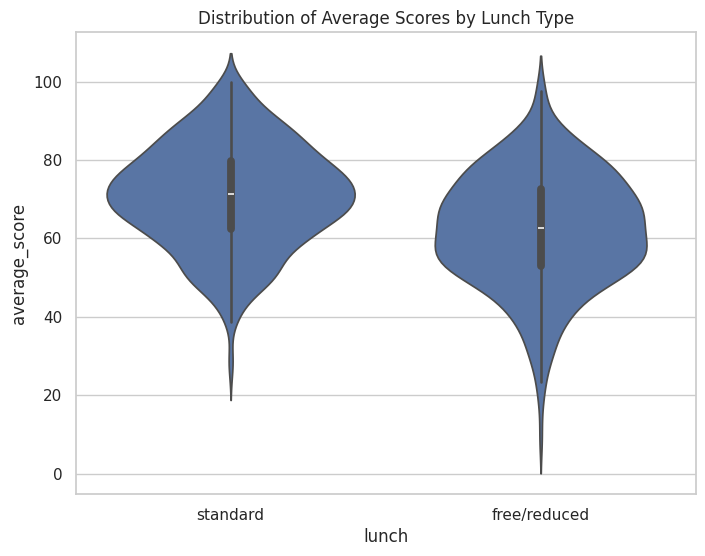

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
# Make sure to provide the correct path to the file.
# If the file is not in your Colab environment, upload it by clicking on the folder icon on the left sidebar,
# then the upload icon, and selecting 'study_performance.csv'.
# Alternatively, if you have the file in Google Drive, you can mount your drive:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/study_performance.csv')
df = pd.read_csv('/content/study_performance.csv')

# Set seaborn style
sns.set(style="whitegrid")

# Regression Analysis
# 1. Prepare the data for regression
# Define predictors and target variable
X = df[['reading_score', 'writing_score', 'gender', 'parental_level_of_education']]
y = df['math_score']

# Use one-hot encoding for categorical variables (e.g., gender, parental_level_of_education)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['reading_score', 'writing_score']),
        ('cat', OneHotEncoder(drop='first'), ['gender', 'parental_level_of_education'])
    ])

# Create a pipeline with preprocessing and linear regression model
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the regression model
pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Calculate and print regression metrics
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R-squared (R2):", r2_score(y_test, y_pred))

# 2. Scatter Plot of Predictions vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title('Actual vs Predicted Math Score')
plt.show()

# 3. Regression Coefficients
# Extract and display coefficients for interpretation
regressor = pipeline.named_steps['regressor']
coefficients = regressor.coef_
feature_names = (preprocessor.named_transformers_['cat'].get_feature_names_out(['gender', 'parental_level_of_education']).tolist()
                 + ['reading_score', 'writing_score'])
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Plot the coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

# K-Means Clustering Analysis
# 1. Prepare the data for clustering
clustering_data = df[['math_score', 'reading_score', 'writing_score']]

# 2. Standardize the data to improve K-means performance
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

# 3. Apply K-means clustering with 3 clusters (you can adjust based on need)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(clustering_data_scaled)

# 4. Plot clusters in a 3D scatter plot (math_score, reading_score, writing_score)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['math_score'], df['reading_score'], df['writing_score'],
                     c=df['cluster'], cmap='viridis', s=50)
ax.set_xlabel('Math Score')
ax.set_ylabel('Reading Score')
ax.set_zlabel('Writing Score')
plt.title('3D Scatter Plot of K-means Clusters')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

# Additional Analysis: Visualizing Cluster Centers
# Create a DataFrame with cluster centers for interpretation
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers, columns=['math_score', 'reading_score', 'writing_score'])

# Plot the cluster centers on a bar chart for easy comparison
centers_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('K-means Cluster Centers')
plt.xlabel('Cluster')
plt.ylabel('Score')
plt.xticks(ticks=range(len(centers_df)), labels=[f'Cluster {i}' for i in range(len(centers_df))], rotation=0)
plt.legend(loc='upper left')
plt.show()

# 1. Distribution of Scores
plt.figure(figsize=(15, 5))
for i, score_type in enumerate(['math_score', 'reading_score', 'writing_score'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[score_type], kde=True, color='blue')
    plt.title(f'Distribution of {score_type.capitalize()}')
plt.tight_layout()
plt.show()

# 2. Boxplots of Scores by Gender
plt.figure(figsize=(15, 5))
for i, score_type in enumerate(['math_score', 'reading_score', 'writing_score'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='gender', y=score_type, data=df)
    plt.title(f'{score_type.capitalize()} by Gender')
plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
score_corr = df[['math_score', 'reading_score', 'writing_score']].corr()
sns.heatmap(score_corr, annot=True, cmap="coolwarm", center=0)
plt.title('Correlation Heatmap of Scores')
plt.show()

# 4. Bar Charts for Average Scores by Parental Education Level
avg_scores_by_education = df.groupby('parental_level_of_education')[['math_score', 'reading_score', 'writing_score']].mean()
avg_scores_by_education.plot(kind='bar', figsize=(12, 6))
plt.title('Average Scores by Parental Education Level')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.show()

# 5. Stacked Bar Chart by Test Preparation Course
prep_course_scores = df.groupby('test_preparation_course')[['math_score', 'reading_score', 'writing_score']].mean()
prep_course_scores.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Scores by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.show()

# 6. Scatter Plots of Score Pairs
sns.pairplot(df[['math_score', 'reading_score', 'writing_score']], plot_kws={'alpha':0.6})
plt.suptitle('Scatter Plot of Score Pairs', y=1.02)
plt.show()

# 7. ROC Curve for Pass/Fail Classification
# Create a 'pass' column where average score >= 60 is a pass
df['average_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)
df['pass'] = np.where(df['average_score'] >= 60, 1, 0)

# Split data for ROC Curve
X = df[['math_score', 'reading_score', 'writing_score']]
y = df['pass']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)
y_probs = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# 8. Heatmap of Average Scores by Gender and Lunch Type
avg_scores = df.pivot_table(index='gender', columns='lunch', values='average_score')
sns.heatmap(avg_scores, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title('Average Scores by Gender and Lunch Type')
plt.show()

# 9. Boxplots of Scores by Race/Ethnicity
plt.figure(figsize=(15, 5))
for i, score_type in enumerate(['math_score', 'reading_score', 'writing_score'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='race_ethnicity', y=score_type, data=df)
    plt.title(f'{score_type.capitalize()} by Race/Ethnicity')
plt.tight_layout()
plt.show()

# 10. Distribution of Average Scores by Lunch Type
plt.figure(figsize=(8, 6))
sns.violinplot(x='lunch', y='average_score', data=df)
plt.title('Distribution of Average Scores by Lunch Type')
plt.show()